# DLW 数值分析 report

以 DLW 单孤子与二孤子的解析解为参照，采用两种可积半离散方法（SD、SD2）和一种直接差分方法（FD）计算数值解，比较固定网格、动网格及不同时间算法下的误差。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.interpolate import CubicSpline
from scipy.sparse import bmat, csc_matrix, coo_matrix, diags
from scipy.sparse.linalg import splu
from IPython.display import display

plt.rcParams.update({'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.linewidth': .7, 'axes.spines.top': False,
    'axes.spines.right': False, 'xtick.direction': 'in',
    'ytick.direction': 'in', 'figure.dpi': 110})

## 1　模型与实验设计

连续 DLW 方程为

$$\begin{aligned}
u_{yt}&=-\partial_x[(u+2a)u_y]-v_{xx},\\
v_t&=-\partial_x[(u+2a)v-4u]-u_{xxy}.
\end{aligned}$$

采用 Sheng–Yu 原文的三组孤子参数，$a=2$、$c_i=1$，初相位为零。A、B 分别对应图 1(a)、1(b)，C 对应图 3；具体 $p_i,q_i$ 如下表。取 $\Delta t=0.000125$、$T=0.01$。

In [2]:
CASES = {'A': ((1.,), (2.,)), 'B': ((4.,), (-3.,)),
         'C': ((6., 4.), (-5., -3.))}
# 计算域为 x∈[-L/2, L/2]；绘图参数在末尾独立设置。
CONFIG = dict(
    a=2., h=.125, yhalf=1.5,       # 方程参数、y 格距、y 半宽
    L=40., nx=256,                 # x 计算域长度、网格点数
    dt=.000125, T=.01,             # 时间步长、终止时间
    eval_half=10., eval_points=4001,  # 误差评价区间 [-eval_half, eval_half]
)
if not (0 < CONFIG['eval_half'] < CONFIG['L']/2):
    raise ValueError('评价区间须位于计算域 (-L/2, L/2) 内。')
MODELS = ('SD', 'SD2', 'FD')
COLORS = dict(SD='#1776bc', SD2='#d47b19', FD='#38965f')
pd.DataFrame([{'算例': k, 'p': p, 'q': q} for k, (p, q) in CASES.items()])


,算例,p,q
0,A,"(1.0,)","(2.0,)"
1,B,"(4.0,)","(-3.0,)"
2,C,"(6.0, 4.0)","(-5.0, -3.0)"


### 1.1　孤子精确解

$x,y$ 为空间坐标，$t$ 为时间。由表中的 $p_i,q_i$ 及 $a=2$，确定

$$S_i=p_i+q_i,\qquad \omega_i=q_i^2-p_i^2,\qquad
\ell_i=\frac1{p_i-a}+\frac1{q_i+a},\qquad
\gamma_i=-\frac{p_i-a}{q_i+a}.$$

在给定的 $(x,y,t)$ 处，记

$$\theta_i(x,y,t)=S_ix+\omega_it+\ell_i y,\qquad
E_i(x,y,t)=e^{\theta_i(x,y,t)}.$$

单孤子的解析式为

$$\begin{aligned}
g(x,y,t)&=1+\frac{E_1(x,y,t)}{S_1},\\
f(x,y,t)&=1+\frac{\gamma_1E_1(x,y,t)}{S_1}.
\end{aligned}$$

二孤子记

$$C_{12}=\frac{(p_1-p_2)(q_1-q_2)}
{(p_1+q_1)(p_1+q_2)(p_2+q_1)(p_2+q_2)},$$

则

$$\begin{aligned}
g(x,y,t)&=1+\frac{E_1(x,y,t)}{S_1}+\frac{E_2(x,y,t)}{S_2}
+C_{12}E_1(x,y,t)E_2(x,y,t),\\
f(x,y,t)&=1+\frac{\gamma_1E_1(x,y,t)}{S_1}+\frac{\gamma_2E_2(x,y,t)}{S_2}
+\gamma_1\gamma_2C_{12}E_1(x,y,t)E_2(x,y,t).
\end{aligned}$$

精确解由这两个解析函数直接求导：

$$\begin{aligned}
u_*(x,y,t)&=2\partial_x[\log f(x,y,t)-\log g(x,y,t)],\\
v_*(x,y,t)&=2\partial_x\partial_y[\log f(x,y,t)+\log g(x,y,t)].
\end{aligned}$$

展开对数导数，即可直接计算其值：

$$\begin{aligned}
u_*(x,y,t)&=2\left[\frac{f_x(x,y,t)}{f(x,y,t)}-\frac{g_x(x,y,t)}{g(x,y,t)}\right],\\
v_*(x,y,t)&=2\Bigg[\frac{f_{xy}(x,y,t)}{f(x,y,t)}
-\frac{f_x(x,y,t)f_y(x,y,t)}{f(x,y,t)^2}\\
&\qquad+\frac{g_{xy}(x,y,t)}{g(x,y,t)}
-\frac{g_x(x,y,t)g_y(x,y,t)}{g(x,y,t)^2}\Bigg].
\end{aligned}$$

这些导数由指数项的解析式得到：$\partial_xE_i=S_iE_i$、$\partial_yE_i=\ell_iE_i$、$\partial_x\partial_yE_i=S_i\ell_iE_i$；交叉项 $E_1E_2$ 的 $x,y$ 指数率分别为 $S_1+S_2$、$\ell_1+\ell_2$。给定 $(x,y,t)$，计算相应的 $f,g$ 及其导数，再代入上式，即得到该点的精确参照值。

精确参照由 `Exact` 类按上述解析式计算；调用 `uv(js, x, t)`，返回指定空间点与时刻的精确参照值。

In [3]:
class Exact:
    def __init__(self, case, h, a=2.):
        p, q = map(np.asarray, CASES[case])
        self.h = h
        s, omega, ell = p+q, q*q-p*p, 1/(p-a)+1/(q+a)
        gamma = np.log(-(p-a)/(q+a))
        if len(p) == 1:
            self.coeff = np.array([1., 1/s[0]])
            subsets = np.array([[0.], [1.]])
        else:
            cross = ((p[0]-p[1])*(q[0]-q[1]) /
                ((p[0]+q[0])*(p[0]+q[1])*(p[1]+q[0])*(p[1]+q[1])))
            self.coeff = np.array([1., 1/s[0], 1/s[1], cross])
            subsets = np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
        self.rates = subsets @ np.stack((s, omega, ell), axis=1)
        self.gamma = subsets @ gamma
        self._key, self._cache = None, {}

    def tau(self, js, x, t, is_f=False):
        y = (np.atleast_1d(js)+.5)*self.h
        logs = (np.log(self.coeff)[:, None, None]
            + self.rates[:, 0, None, None]*np.atleast_1d(x)[None, None, :]
            + self.rates[:, 1, None, None]*t
            + self.rates[:, 2, None, None]*y[None, :, None])
        if is_f:
            logs = logs + self.gamma[:, None, None]
        total = logsumexp(logs, axis=0)
        return total, np.exp(logs-total[None, :, :])

    def mean(self, w, k):
        return np.einsum('i,ijk->jk', self.rates[:, k], w)

    def cov(self, w, a, b):
        return (np.einsum('i,ijk->jk', self.rates[:, a]*self.rates[:, b], w)
                - self.mean(w, a)*self.mean(w, b))

    def uv(self, js, x, t):
        key = (float(t), np.asarray(x).tobytes())
        if key != self._key:
            self._key, self._cache = key, {}
        sub = tuple(np.atleast_1d(js))
        if sub not in self._cache:
            _, f = self.tau(js, x, t, True)
            _, g = self.tau(js, x, t)
            self._cache[sub] = (2*(self.mean(f, 0)-self.mean(g, 0)),
                2*(self.cov(f, 0, 2)+self.cov(g, 0, 2)))
        return tuple(v.copy() for v in self._cache[sub])

## 2　空间离散与边界

$x\in[-20,20)$ 分为 256 份，$\Delta x=40/256=0.15625$；$y\in[-1.5,1.5]$ 分为 24 份，$h=0.125$，场值取各份中点。

记 $\delta_-f_j=(f_j-f_{j-1})/h$、$\delta_0f_j=(f_{j+1}-f_{j-1})/(2h)$、$M_-f_j=(f_j+f_{j-1})/2$。$x$ 向采用三点二阶中心差分；二阶导数与 GSG 对照格式的式 (4.13)–(4.14) 使用相同的三点算子：

$$D_1f_i=\frac{f_{i+1}-f_{i-1}}{2\Delta x},\qquad D_2f_i=\frac{f_{i+1}-2f_i+f_{i-1}}{\Delta x^2}.$$

$y$ 下侧取解析值，上侧虚点取解析背景加扰动的二次外推；SD、FD 的 $x$ 差分按周期延拓，SD2 按端点跃变量延拓。

**对应代码。** 下方定义共用网格、三点差分与场值恢复。

In [4]:
class Grid:
    def __init__(self, n, L):
        self.n, self.L, self.dx = n, L, L/n
        self.xi = -L/2 + np.arange(n)*self.dx
        ii = np.arange(n)
        self.Dxi = coo_matrix((np.concatenate([np.full(n, c/(2*self.dx))
            for c in (-1, 1)]), (np.tile(ii, 2),
            np.concatenate([(ii+k) % n for k in (-1, 1)]))),
            shape=(n, n)).tocsr()
        self.Dxxi = coo_matrix((np.concatenate([np.full(n, c/self.dx**2)
            for c in (1, -2, 1)]), (np.tile(ii, 3),
            np.concatenate([(ii+k) % n for k in (-1, 0, 1)]))),
            shape=(n, n)).tocsr()
        self.set_s(np.zeros(n))

    def neighbors(self, f, jump=0.):
        # f(xi+L)=f(xi)+jump；周期场取 jump=0。
        f = np.asarray(f, dtype=np.result_type(f, jump, float))
        left, right = np.roll(f, 1, axis=-1), np.roll(f, -1, axis=-1)
        left[..., :1] -= jump
        right[..., -1:] += jump
        return left, right

    def dxi(self, f, jump=0.):
        left, right = self.neighbors(f, jump)
        return (right-left)/(2*self.dx)

    def dxxi(self, f, jump=0.):
        left, right = self.neighbors(f, jump)
        return (right-2*f+left)/self.dx**2

    def set_s(self, s):
        self.s = np.asarray(s).copy()
        self.x, self.J = self.xi+self.s, 1+self.dxi(self.s)
        self.Jxi = self.dxi(self.J)
        if self.J.min() <= 0 or np.diff(np.r_[self.x, self.x[0]+self.L]).min() <= 0:
            raise ValueError('网格 Jacobian 非正或节点交叉')

    def d1(self, f, jump=0.):
        return self.dxi(f, jump)/self.J

    def d2(self, f, jump=0.):
        return (self.dxxi(f, jump)/self.J**2
                -self.Jxi*self.dxi(f, jump)/self.J**3)

def delta0(u, ghosts, h):
    ext = np.concatenate((ghosts[0][None, :], u, ghosts[1][None, :]))
    return (ext[2:]-ext[:-2])/(2*h)

def ghost_u(G, js, x, t, u):
    gl, gr = G.uv([js[0]-1, js[-1]+1], x, t)[0]
    # 上侧外推扰动；解析背景与内部数值解分开处理。
    e = u[-3:]-G.uv(js[-3:], x, t)[0]
    return gl, gr+3*e[-1]-3*e[-2]+e[-3]

In [5]:
class PhysicalModel:
    def __init__(self, case, model, config):
        self.kind, self.h, self.a = model, config['h'], config['a']
        self.X = Grid(config['nx'], config['L'])
        self.G = Exact(case, self.h, self.a)
        n = round(config['yhalf']/self.h)
        self.js = np.arange(-n, n)
        self.y = (self.js+.5)*self.h
        self.shape = (len(self.js), self.X.n)
        self.np = (len(self.js)-1)*self.X.n

    def pack(self, p, w):
        return np.r_[p.ravel(), w.ravel()]

    def unpack(self, z):
        return z[:self.np].reshape(self.shape[0]-1, -1), z[self.np:].reshape(self.shape)

    def recover_u(self, p, t):
        base = self.G.uv([self.js[0]], self.X.x, t)[0][0]
        return np.vstack((base, base+self.h*np.cumsum(p, axis=0)))

    def initial(self):
        u, v = self.G.uv(self.js, self.X.x, 0.)
        ghosts = self.G.uv([self.js[0]-1, self.js[-1]+1], self.X.x, 0.)[0]
        w = v
        return self.pack(np.diff(u, axis=0)/self.h, w)

    def fields(self, z, t):
        p, w = self.unpack(z)
        u = self.recover_u(p, t)
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        return u, w

### 2.1　SD

**半离散非线性方程。** 以 $u_j,\omega_j$ 表示第一种非线性形式：

$$\begin{aligned}
\delta_-u_{j,t}
&+\partial_x\delta_-\left[\frac{u_j^2+\omega_j^2}{2}+2au_j-h\omega_j\right]
+\partial_x^2\left(\delta_-u_j+\frac4hM_-\omega_j\right)=0,\\
\omega_{j,t}&+\partial_x[(u_j+2a)\omega_j-hu_j]-\omega_{j,xx}=0.
\end{aligned}$$

$\omega_j=\partial_x(\log G_{j+1}-\log G_j)$，物理场为 $v_j=4\omega_j/h+\delta_0u_j$。取演化变量

$$P_j=\delta_-u_j,\qquad W_j=\frac4h\omega_j=v_j-\delta_0u_j,$$

并记

$$H_j=\frac{u_j^2}{2}+2au_j+h^2\left(\frac{W_j^2}{32}-\frac{W_j}{4}\right).$$

上式成为

$$\begin{aligned}
P_{j,t}&=-\delta_-\partial_xH_j-\partial_x^2(P_j+M_-W_j),\\
W_{j,t}&=-\partial_x[(u_j+2a)W_j-4u_j]+\partial_x^2W_j.
\end{aligned}$$

**离散递推。** 每个时间级先由下侧解析边界恢复

$$u_{j,i}(t)=u_{j_L,i}(t)+h\sum_{k=j_L+1}^{j}P_{k,i}(t),\qquad
v=W+\delta_0u,$$

再计算

$$\begin{aligned}
F_P&=-\delta_-D_1H-D_2(P+M_-W),\\
F_W&=-D_1[(u+2a)W-4u]+D_2W,\\
P^{n+1}&=P^n+\Delta t\,F_P(t_n),\qquad
W^{n+1}=W^n+\Delta t\,F_W(t_n).
\end{aligned}$$

参数：$a=2$、$h=0.125$、$\Delta x=0.15625$、$\Delta t=0.000125$、$T=0.01$。初值为 $P^0=\delta_-u_*(0)$、$W^0=v_*(0)-\delta_0u_*(0)$，$u_{j_L}(t)$ 取解析值。以上为 Euler 更新；同一右端的 RK4 更新见第 3 节。

**对应代码。** `pt`、`wt` 分别是 $F_P,F_W$；`axis=0` 沿 $y$，`d1,d2` 沿 $x$。

In [6]:
class SDModel(PhysicalModel):
    def initial(self):
        u, v = self.G.uv(self.js, self.X.x, 0.)
        ghosts = self.G.uv([self.js[0]-1, self.js[-1]+1], self.X.x, 0.)[0]
        # P = delta_- u, W = 4 omega / h = v - delta_0 u.
        return self.pack(np.diff(u, axis=0)/self.h,
                         v-delta0(u, ghosts, self.h))

    def fields(self, z, t):
        p, w = self.unpack(z)
        u = self.recover_u(p, t)
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        return u, w+delta0(u, ghosts, self.h)

    def rhs(self, t, z):
        p, w = self.unpack(z)
        u = self.recover_u(p, t)
        d1, d2, h, a = self.X.d1, self.X.d2, self.h, self.a
        # This is Report (7) after omega = h W / 4.
        H = u*u/2+2*a*u+h*h*(w*w/32-w/4)
        pt = -np.diff(d1(H), axis=0)/h-d2(p+(w[1:]+w[:-1])/2)
        wt = -d1((u+2*a)*w-4*u)+d2(w)
        return self.pack(pt, wt)

### 2.2　SD2

**原半离散方程。** 以 $Q,R$ 为演化变量：

$$\begin{aligned}
Q_{j,t}&=-Q_{j,xx}-2aQ_{j,x}-\left[(M_j+M_{j+1})_x+\frac{h^2}{4}(Q_j^2R_j^2-1)\right]Q_j,\\
R_{j,t}&=R_{j,xx}-2aR_{j,x}+\left[(M_j+M_{j+1})_x+\frac{h^2}{4}(Q_j^2R_j^2-1)\right]R_j,\\
M_{j+1}-M_j&=h(1-Q_jR_j).
\end{aligned}$$

**离散递推。** 令 $S_j=Q_jR_j$、$G_j=h^2(S_j^2-1)/4$、$m_j=M_{j,x}$，下边界确定 $Q_0,Q_{0,t}$，然后计算

$$\begin{aligned}
m_0&=-\frac{Q_{0,t}+D_2Q_0+2aD_1Q_0}{2Q_0}-\frac{G_0}{2}+\frac h2D_1S_0,\\
m_{j+1}&=m_j-hD_1S_j,\qquad A_j=m_j+m_{j+1},\\
F_Q&=-D_2Q-2aD_1Q-(A+G)Q,\\
F_R&=D_2R-2aD_1R+(A+G)R,\\
Q_j^{n+1}&=Q_j^n+\Delta t\,F_{Q,j}(t_n)\quad(j\ge1),\qquad
R_j^{n+1}=R_j^n+\Delta t\,F_{R,j}(t_n)\quad(j\ge0),\\
u&=2(D_1Q)/Q,\qquad v=4(1-QR)+\delta_0u.
\end{aligned}$$

参数：$a=2$、$h=0.125$、$\Delta x=0.15625$、$\Delta t=0.000125$、$T=0.01$。初值与下边界通过

$$D_1Q_j^0=\tfrac12u_j^0Q_j^0,\qquad Q_{j,0}^0=1,\qquad
R_j^0=\frac{1-(v_j^0-\delta_0u_j^0)/4}{Q_j^0}$$

确定。下边界每个时间级求解 $D_1Q_0(t)=u_{*,0}(t)Q_0(t)/2$、$Q_{0,0}(t)=1$；这里的 $D_1$ 使用代码 `dx` 的端点跃变量修正。内部 $Q$ 与全部 $R$ 按上述右端推进，Euler 与 RK4 共用此右端。

**对应代码。** 先定义初值与下边界的求解，再定义递推；代码中的 `w` 对应 $S$、`H` 对应 $G$、`mx` 对应 $m$。

In [7]:
class SD2Lift(PhysicalModel):
    def __init__(self, case, config):
        super().__init__(case, 'SD2', config)
        n, dx = self.X.n, self.X.dx
        self.D = self.X.Dxi.tocsc()
        self.b = np.zeros(n)
        self.b[0] = self.b[-1] = 1/(2*dx)
        self.norm = csc_matrix(([1.], ([0], [0])), shape=(1, n))
        self.initial_right, self._boundary_key = None, None
        self.jump = self.rjump = 0.

    def dx(self, f, jump=0.):
        return self.X.d1(f, jump)

    def lift(self, u):
        A = bmat([[self.D-diags(.5*self.X.J*u), csc_matrix(self.b[:, None])],
                  [self.norm, csc_matrix((1, 1))]], format='csc')
        lu = splu(A)
        sol = lu.solve(np.r_[np.zeros(self.X.n), 1.])
        q, jump = sol[:-1], sol[-1]
        if q.min() <= 0 or 1+jump <= 0:
            raise ValueError('SD2 提升后的 Q 或端点比值非正')
        return q, jump, lu

    def boundary(self, t):
        key = (float(t), self.X.x.tobytes(), self.X.J.tobytes())
        if key != self._boundary_key:
            _, f = self.G.tau([self.js[0]], self.X.x, t, True)
            _, g = self.G.tau([self.js[0]], self.X.x, t)
            u = 2*(self.G.mean(f, 0)-self.G.mean(g, 0))[0]
            ut = 2*(self.G.cov(f, 0, 1)-self.G.cov(g, 0, 1))[0]
            ux = 2*(self.G.cov(f, 0, 0)-self.G.cov(g, 0, 0))[0]
            q, jump, lu = self.lift(u)
            self._boundary_key = key
            self._boundary_value = q, jump, lu, u, ut, ux
        q, jump, lu, u, ut, ux = self._boundary_value
        if self.initial_right is not None:
            right = self.initial_right*(1+jump)/self.initial_right[0]
            self.jump, self.rjump = (right-1)[:, None], (1/right-1)[:, None]
        return self._boundary_value

    def boundary_derivative(self, t, velocity):
        q, jump, lu, u, ut, ux = self.boundary(t)
        rhs = .5*(self.D@velocity*u+self.X.J*(ut+velocity*ux))*q
        material_qt = lu.solve(np.r_[rhs, 0.])[:-1]
        qx = (self.D@q+self.b*jump)/self.X.J
        return material_qt-velocity*qx

    def pack(self, q, r):
        return np.r_[q[1:].ravel(), r.ravel()]

    def unpack(self, z, t):
        q = np.vstack((self.boundary(t)[0], z[:self.np].reshape(self.shape[0]-1, -1)))
        return q, z[self.np:].reshape(self.shape)

    def initial(self):
        u, v = self.G.uv(self.js, self.X.x, 0.)
        lifted = [self.lift(row) for row in u]
        q = np.array([v[0] for v in lifted])
        self.initial_right = 1+np.array([v[1] for v in lifted])
        self._boundary_key = None
        self.boundary(0.)
        ghosts = self.G.uv([self.js[0]-1, self.js[-1]+1], self.X.x, 0.)[0]
        r = (1-(v-delta0(u, ghosts, self.h))/4)/q
        return self.pack(q, r)

In [8]:
class SD2Model(SD2Lift):
    def fields(self, z, t):
        q, r = self.unpack(z, t)
        u = 2*self.dx(q, self.jump)/q
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        return u, 4*(1-q*r)+delta0(u, ghosts, self.h)

    def stage(self, t, state, mesh):
        self.X.set_s(state[-self.X.n:])
        q, r = self.unpack(state[:-self.X.n], t)
        if q.min() <= 0:
            raise ValueError('演化后的 Q 非正')
        qx, rx = self.dx(q, self.jump), self.dx(r, self.rjump)
        w = q*r
        velocity = np.zeros(self.X.n)
        if mesh == 'moving':
            density = w.mean(axis=0)
            flux = ((2*qx/q+2*self.a)*w-self.dx(w)-2*self.a).mean(axis=0)
            if density.min() <= 0:
                raise ValueError('动网格监测密度非正')
            velocity = (flux-flux[0])/density
        qt0 = self.boundary_derivative(t, velocity)
        qxx = self.X.d2(q, self.jump)
        rxx, wx = self.X.d2(r, self.rjump), self.dx(w)
        H = self.h**2/4*(w*w-1)
        A0 = -(qt0+qxx[0]+2*self.a*qx[0])/q[0]-H[0]
        mx0 = (A0+self.h*wx[0])/2
        mx = mx0-self.h*np.vstack((np.zeros(self.X.n), np.cumsum(wx, axis=0)))
        A = mx[:-1]+mx[1:]
        qt = -qxx-2*self.a*qx-(A+H)*q
        rt = rxx-2*self.a*rx+(A+H)*r
        return np.r_[self.pack(qt+velocity*qx, rt+velocity*rx), velocity]

### 2.3　FD

**原连续方程。**

$$\begin{aligned}
u_{yt}&=-\partial_x[(u+2a)u_y]-v_{xx},\\
v_t&=-\partial_x[(u+2a)v-4u]-u_{xxy}.
\end{aligned}$$

**离散递推。** 取 $P=\delta_-u$，每个时间级由 $u_{j,i}=u_{j-1,i}+hP_{j,i}$ 恢复 $u$，然后计算

$$\begin{aligned}
F_P&=-\delta_-D_1\left(\frac{u^2}{2}+2au\right)-D_2M_-v,\\
F_v&=-D_1[(u+2a)v-4u]-D_2\delta_0u,\\
P^{n+1}&=P^n+\Delta t\,F_P(t_n),\qquad v^{n+1}=v^n+\Delta t\,F_v(t_n).
\end{aligned}$$

参数：$a=2$、$h=0.125$、$\Delta x=0.15625$、$\Delta t=0.000125$、$T=0.01$。初值为 $P^0=\delta_-u_*(0)$、$v^0=v_*(0)$。Euler 与 RK4 共用此右端。

**对应代码。** `fp`、`fv` 分别是 $F_P,F_v$，`uy` 是 $\delta_0u$。

In [9]:
class FDModel(PhysicalModel):
    def rhs(self, t, z):
        p, v = self.unpack(z)
        u = self.recover_u(p, t)
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        uy = delta0(u, ghosts, self.h)
        d1, d2, h, a = self.X.d1, self.X.d2, self.h, self.a
        fp = -np.diff(d1(u*u/2+2*a*u), axis=0)/h-d2((v[1:]+v[:-1])/2)
        fv = -d1((u+2*a)*v)-d2(uy)+4*d1(u)
        return self.pack(fp, fv)

### 2.4　网格策略

固定网格取 $s=0$、$V=0$。动网格初始节点按 $\bar\rho$ 的累积积分等分，之后使用

$$\begin{aligned}
x_i&=\xi_i+s_i,\qquad J_i=1+D_\xi s_i,\qquad D_1=J^{-1}D_\xi,\\
D_2f&=J^{-2}D_{\xi\xi}f-J^{-3}(D_\xi J)(D_\xi f),\\
\rho_j&=1-(v_j-\delta_0u_j)/4,\qquad
\bar\rho=\frac1{24}\sum_j\rho_j,\\
\bar q&=\frac1{24}\sum_j[(u_j+2a)\rho_j-D_1\rho_j-2a],\qquad
V_i=\frac{\bar q_i-\bar q_0}{\bar\rho_i},\\
\dot x_i&=V_i,\qquad \dot z=\mathcal F(t,z)+VD_1z.
\end{aligned}$$

$D_\xi$、$D_{\xi\xi}$ 为前述三点二阶中心差分，$\Delta\xi=0.15625$；节点与场值同步使用 Euler 或 RK4 更新。

In [10]:
class Problem:
    def __init__(self, case, model, mesh, config=CONFIG):
        self.mesh, self.model = mesh, model
        self.m = SD2Model(case, config) if model == 'SD2' else (SDModel if model == 'SD' else FDModel)(case, model, config)
        self.X = self.m.X

    def initial(self):
        if self.mesh == 'moving':
            x = np.linspace(-self.X.L/2, self.X.L/2, 40001)
            u, v = self.m.G.uv(self.m.js, x, 0.)
            gh = self.m.G.uv([self.m.js[0]-1, self.m.js[-1]+1], x, 0.)[0]
            density = 1-(v-delta0(u, gh, self.m.h)).mean(axis=0)/4
            if density.min() <= 0:
                raise ValueError('初始监测密度非正')
            mass = np.r_[0, np.cumsum((density[:-1]+density[1:])*np.diff(x)/2)]
            nodes = np.interp(np.arange(self.X.n)/self.X.n*mass[-1], mass, x)
            self.X.set_s(nodes-self.X.xi)
        return np.r_[self.m.initial(), self.X.s]

    def fields(self, state, t):
        self.X.set_s(state[-self.X.n:])
        return self.m.fields(state[:-self.X.n], t)

    def stage(self, t, state):
        if self.model == 'SD2':
            return self.m.stage(t, state, self.mesh)
        z = state[:-self.X.n]
        self.X.set_s(state[-self.X.n:])
        physical = self.m.rhs(t, z)
        velocity = np.zeros(self.X.n)
        if self.mesh == 'moving':
            u, v = self.m.fields(z, t)
            ghosts = ghost_u(self.m.G, self.m.js, self.X.x, t, u)
            rho = 1-(v-delta0(u, ghosts, self.m.h))/4
            density = rho.mean(axis=0)
            flux = ((u+2*self.m.a)*rho-self.X.d1(rho)-2*self.m.a).mean(axis=0)
            if density.min() <= 0:
                raise ValueError('动网格监测密度非正')
            velocity = (flux-flux[0])/density
            p, w = self.m.unpack(z)
            physical += self.m.pack(self.X.d1(p)*velocity, self.X.d1(w)*velocity)
        return np.r_[physical, velocity]

## 3　时间推进与误差评价

三种方案分别以第 2 节的离散右端 $\mathcal F$ 推进。Euler 更新为 $z^{n+1}=z^n+\Delta t\,\mathcal F(t_n,z^n)$；RK4 的递推为

$$\begin{aligned}
k_1&=\mathcal F(t_n,z^n),\\
k_2&=\mathcal F\left(t_n+\frac{\Delta t}{2},z^n+\frac{\Delta t}{2}k_1\right),\\
k_3&=\mathcal F\left(t_n+\frac{\Delta t}{2},z^n+\frac{\Delta t}{2}k_2\right),\\
k_4&=\mathcal F(t_n+\Delta t,z^n+\Delta t k_3),\\
z^{n+1}&=z^n+\frac{\Delta t}{6}(k_1+2k_2+2k_3+k_4).
\end{aligned}$$

状态与节点使用同一时间算法同步更新。

在 $x\in[-10,10]$ 的 4001 个等距点及全部 $y$ 层上，三次样条重构数值场，计算

$$E_f(T)=\max_{(x,y)\in\mathcal G}|f_h(x,y,T)-f_*(x,y,T)|,\qquad f\in\{u,v\}.$$

三种方案从相同的物理初值 $u_*(0),v_*(0)$ 出发。

时间算法比较另加入 Crank–Nicolson（C–N）：

$$z^{n+1}=z^n+\frac{\Delta t}{2}\left[\mathcal F(t_n,z^n)+\mathcal F(t_{n+1},z^{n+1})\right].$$

这是二阶隐式梯形法，采用迭代求解并检查隐式方程残差。


In [11]:
def step(fun, t, state, dt, method):
    if method == 'Euler':
        return state+dt*fun(t, state)
    if method == 'CN':
        # 隐式梯形法：两端右端的平均，不是中点状态的右端。
        f0 = fun(t, state)
        candidate = state+dt*f0
        tolerance = 1e-12+1e-11*max(1., float(np.max(abs(state))))
        for iteration in range(1, 81):
            residual = candidate-state-dt*(f0+fun(t+dt, candidate))/2
            residual_max = float(np.max(abs(residual)))
            if residual_max <= tolerance:
                step.cn_last = dict(iterations=iteration, residual=residual_max, tolerance=tolerance)
                return candidate
            candidate = candidate-residual
        raise ValueError(f'Crank–Nicolson 隐式迭代未收敛：残差 {residual_max:.3e}')
    if method != 'RK4':
        raise ValueError('时间算法应为 Euler、RK4 或 CN')
    k1 = fun(t, state)
    k2 = fun(t+dt/2, state+dt*k1/2)
    k3 = fun(t+dt/2, state+dt*k2/2)
    k4 = fun(t+dt, state+dt*k3)
    return state+dt*(k1+2*k2+2*k3+k4)/6

def solve(case, model, method, mesh, config=CONFIG):
    if method not in ('Euler', 'RK4', 'CN'):
        raise ValueError('时间算法应为 Euler、RK4 或 CN')
    p = Problem(case, model, mesh, config)
    state = p.initial()
    initial = p.fields(state, 0.)
    initial_ref = p.m.G.uv(p.m.js, p.X.x, 0.)
    mask = abs(p.X.x) <= config['eval_half']
    initial_error = max(float(abs(u[:, mask]-v[:, mask]).max())
                        for u, v in zip(initial, initial_ref))
    nsteps = round(config['T']/config['dt'])
    if not np.isclose(nsteps*config['dt'], config['T'], rtol=0, atol=1e-13):
        raise ValueError('T 必须是 dt 的整数倍')
    reached, reason = 0., ''
    cn_diagnostics = []
    for n in range(nsteps):
        try:
            with np.errstate(over='raise', invalid='raise', divide='raise'):
                candidate = step(p.stage, n*config['dt'], state, config['dt'], method)
                if method == 'CN':
                    cn_diagnostics.append(dict(step.cn_last))
                if not np.all(np.isfinite(candidate)) or abs(candidate).max() > 1000:
                    raise ValueError('状态非有限或绝对值超过 1000')
                p.X.set_s(candidate[-p.X.n:])
        except (ValueError, FloatingPointError, OverflowError) as e:
            reason = str(e)
            break
        state, reached = candidate, (n+1)*config['dt']
    xx = np.linspace(-config['eval_half'], config['eval_half'], config['eval_points'])
    native = p.fields(state, reached)
    sampled = [CubicSpline(p.X.x, f, axis=-1)(xx) for f in native]
    exact = p.m.G.uv(p.m.js, xx, reached)
    errors = {f: abs(u-v) for f, u, v in zip(('u', 'v'), sampled, exact)}
    return dict(case=case, model=model, method=method, mesh=mesh,
        reached=reached, completed=not reason and np.isclose(reached, config['T']), reason=reason,
        initial_error=initial_error, x=xx, y=p.m.y, fields=sampled, exact=exact,
        errors=errors, max_errors={f: float(e.max()) for f, e in errors.items()},
        min_J=float(p.X.J.min()), native_x=p.X.x.copy(), native_fields=native,
        cn_diagnostics=cn_diagnostics)

results = {}
def calculate(method, mesh):
    for case in CASES:
        for model in MODELS:
            key = case, model, method, mesh
            if key not in results:
                results[key] = solve(case, model, method, mesh)
    failed = [r for r in results.values() if not r['completed']]
    if failed:
        display(pd.DataFrame([{k: r[k] for k in ('case', 'model', 'method', 'mesh', 'reached', 'reason')}
                             for r in failed]))
        raise RuntimeError('未到达共同终点，停止配对比较')

def error_table(method, mesh):
    return pd.DataFrame([{'算例': case, '场': field,
        **{m: results[case, m, method, mesh]['max_errors'][field] for m in MODELS}}
        for case in CASES for field in ('u', 'v')]).set_index(['算例', '场'])

## 4　空间方案的比较

在均匀固定网格上比较三种方案，时间算法统一为 RK4，时间步长为 $0.000125$，终点为 $T=0.01$。每行加粗值为最小误差。

In [12]:
calculate('RK4', 'fixed')
space_table = error_table('RK4', 'fixed')
space_table.style.format('{:.3e}').highlight_min(axis=1, props='font-weight: bold')

## 5　时间算法的比较

在固定网格上分别比较 SD、SD2、FD 的 Euler、RK4 与 Crank–Nicolson。保持相同的初值、空间格距、时间步长 $\Delta t=0.000125$ 和终点 $T=0.01$。其他实验的时间算法保持原设置。

In [13]:
calculate('Euler', 'fixed')
calculate('CN', 'fixed')
time_table = pd.DataFrame([{'算例': case, '方案': model, '场': field,
    **{('Crank–Nicolson' if method == 'CN' else method): results[case, model, method, 'fixed']['max_errors'][field]
       for method in ('Euler', 'RK4', 'CN')}}
    for case in CASES for model in MODELS for field in ('u', 'v')]).set_index(['算例', '方案', '场'])
time_table.style.format('{:.3e}').highlight_min(axis=1, props='font-weight: bold')

取 $\Delta t$、$\Delta t/2$、$\Delta t/4$，以相邻时间步长的数值场差估计时间阶：

$$p_f=\log_2\frac{\|f_{\Delta t}-f_{\Delta t/2}\|_{\infty,\mathcal G}}
{\|f_{\Delta t/2}-f_{\Delta t/4}\|_{\infty,\mathcal G}}.$$

下面计算 SD 与 SD2 在 Euler 更新下的时间观测阶。

In [14]:
order_rows = []
refinement_rows = []
for case in CASES:
    for model in ('SD', 'SD2'):
        fields = [results[case, model, 'Euler', 'fixed']['fields']]
        for divisor in (2, 4):
            refined = solve(case, model, 'Euler', 'fixed',
                            dict(CONFIG, dt=CONFIG['dt']/divisor))
            if not refined['completed']:
                raise RuntimeError(refined['reason'])
            fields.append(refined['fields'])
            refinement_rows.append(dict(case=case, model=model, method='Euler',
                mesh='fixed', dt=CONFIG['dt']/divisor, reached=refined['reached'],
                completed=bool(refined['completed']), min_J=refined['min_J']))
        for i, field in enumerate(('u', 'v')):
            d1 = np.max(abs(fields[0][i]-fields[1][i]))
            d2 = np.max(abs(fields[1][i]-fields[2][i]))
            order_rows.append({'算例': case, '方案': model, '场': field,
                              'dt 与 dt/2 场差': d1, 'dt/2 与 dt/4 场差': d2,
                              '观测阶': np.log2(d1/d2)})
pd.DataFrame(order_rows).set_index(['算例', '方案', '场']).style.format({
    'dt 与 dt/2 场差': '{:.3e}', 'dt/2 与 dt/4 场差': '{:.3e}', '观测阶': '{:.4f}'})

## 6　固定网格与动网格的比较

保持节点数与时间步长一致，三种方案均使用 RK4，比较固定网格与动网格。

In [15]:
calculate('RK4', 'moving')
mesh_table = pd.DataFrame([{'算例': case, '方案': model, '场': field,
    **{mesh: results[case, model, 'RK4', mesh]['max_errors'][field]
       for mesh in ('fixed', 'moving')}}
    for case in CASES for model in MODELS for field in ('u', 'v')]).set_index(['算例', '方案', '场'])
mesh_table.style.format('{:.3e}').highlight_min(axis=1, props='font-weight: bold')

## 7　结果

配对表给出空间方案的最小误差与动网格相对固定网格的误差比；比值小于 1 表示该场误差降低。

In [16]:
for case in CASES:
    best_u = space_table.loc[(case, 'u')].idxmin()
    best_v = space_table.loc[(case, 'v')].idxmin()
    print(f'算例 {case}：RK4 固定网格下，u / v 的最小误差方案为 {best_u} / {best_v}。')
mesh_ratios = mesh_table['moving']/mesh_table['fixed']
ratio_table = mesh_ratios.unstack('场').rename(columns={'u': 'u 动格/固定', 'v': 'v 动格/固定'})
display(ratio_table.style.format('{:.3f}'))
print(f'全部 {len(results)} 组主试验到达 T={CONFIG["T"]:g}；'
      f'初始物理场的最大节点差为 {max(r["initial_error"] for r in results.values()):.3e}。')

算例 A：RK4 固定网格下，u / v 的最小误差方案为 FD / FD。
算例 B：RK4 固定网格下，u / v 的最小误差方案为 SD / SD2。
算例 C：RK4 固定网格下，u / v 的最小误差方案为 SD / FD。


全部 27 组主试验到达 T=0.01；初始物理场的最大节点差为 1.975e-13。


参考资料：H.-H. Sheng and G.-F. Yu, *Solitons, breathers and rational solutions for a (2+1)-dimensional dispersive long wave system*, Physica D 432 (2022), 133140。

## 8　物理场与误差分布

固定 $t=0.01$，A 在 $x\in[-3,4]$、$y\in[-3,3]$ 展示完整波谷；B、C 在 $x,y\in[-30,30]$ 展示全貌。每个算例上行为 $u$，下行为 $v$；三列依次为数值曲面、数值二维彩图、解析二维彩图，后两者共用色标与等高线高度。物理场零值为白色，负值为蓝色，正值为红色；另图显示绝对误差曲面和二维误差分布，零误差也为白色。

场图采用 SD2、RK4 与固定网格；实际计算域扩大为 $x\in[-40,40)$、$y\in[-30,30)$，保持 $\Delta x=0.15625$、$h=0.125$、$\Delta t=0.000125$。此前误差表仍取各自的原计算与评价范围。A、B 为单孤子，C 的两条相互作用波脊在宽 $y$ 范围内可分辨。

In [17]:
# 与前面的误差表分开准备宽域场图；保持原空间、时间步长。
# 改变计算范围、方案或时间后运行本单元；只改 PLOT_CONFIG 不用运行它。
FIELD_CONFIG = dict(CONFIG, L=80., nx=512, yhalf=30.,
                    eval_half=30., eval_points=1201)
FIELD_MODEL, FIELD_METHOD, FIELD_MESH = 'SD2', 'RK4', 'fixed'
if not 0 < FIELD_CONFIG['eval_half'] < FIELD_CONFIG['L']/2:
    raise ValueError('场图评价范围须位于 x 计算域内部。')
if FIELD_CONFIG['yhalf'] <= 0 or FIELD_CONFIG['h'] <= 0:
    raise ValueError('y 计算域半宽与格距必须为正。')
dlw_field_cache = globals().get('dlw_field_cache', {})
field_signature = (tuple(sorted(FIELD_CONFIG.items())), FIELD_MODEL, FIELD_METHOD, FIELD_MESH)
for field_case in CASES:
    cache_key = field_signature, field_case
    if cache_key not in dlw_field_cache:
        computed = solve(field_case, FIELD_MODEL, FIELD_METHOD, FIELD_MESH, FIELD_CONFIG)
        if not computed['completed']:
            raise RuntimeError(f"Case {field_case} 未达到指定时间：{computed['reason']}")
        dlw_field_cache[cache_key] = computed
print(f"场数据已准备：{FIELD_MODEL}, {FIELD_METHOD}, {FIELD_MESH}, T={FIELD_CONFIG['T']:g}。")

场数据已准备：SD2, RK4, fixed, T=0.01。


绘图参数集中在下方；改变展示范围、颜色、等高线数量或视角后，只需运行配置与最后的画图单元。超出已计算范围时，需要先扩大场数据计算域。

In [4]:
# 只调整下面的绘图参数，并重运行本单元与最后的画图单元。
# 不改变已经计算好的数值场；时间取 FIELD_CONFIG['T']。
PLOT_CONFIG = dict(
    cases=('A', 'B', 'C'),
    windows={
        'A': dict(xlim=(-3., 4.), ylim=(-3., 3.)),
        'B': dict(xlim=(-30., 30.), ylim=(-30., 30.)),
        'C': dict(xlim=(-30., 30.), ylim=(-30., 30.)),
    },
    # KP 参考图：jet 彩色等高线，二维白底；可改为 map_style='mesh'。
    cmap='jet', error_cmap='jet', map_style='contour', levels=11, contour_width=1.1,
    elev=28., azim=-62.,
)

In [5]:
from matplotlib.colors import Normalize, BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

def checked_window(window, available, label):
    lo, hi = window
    if not np.isfinite([lo, hi]).all() or lo >= hi:
        raise ValueError(f'{label} 必须是有限且递增的 (下限, 上限)。')
    if lo < available[0]-1e-10 or hi > available[1]+1e-10:
        raise ValueError(f'{label}={window} 超出已计算范围 {available}；请扩大计算域后重新准备场数据。')
    return lo, hi

def draw_field_panels(x, y, numerical, exact, title, names, config, second_axis='y'):
    # 只裁剪已有数据；完整数组保留，改变展示参数不会触发计算。
    xm = (x >= config['xlim'][0]) & (x <= config['xlim'][1])
    ym = (y >= config['ylim'][0]) & (y <= config['ylim'][1])
    if xm.sum() < 3 or ym.sum() < 2:
        raise ValueError('绘图区间至少需要三个 x 点和两个纵向采样点。')
    xx, yy = x[xm], y[ym]
    X, Y = np.meshgrid(xx, yy)
    fig = plt.figure(figsize=(14, 8.5), layout='constrained')
    grid = fig.add_gridspec(2, 3, width_ratios=(1.15, 1, 1))
    cropped = []
    for row, name in enumerate(names):
        n = numerical[row][np.ix_(ym, xm)]
        e = exact[row][np.ix_(ym, xm)]
        cropped.append(abs(n-e))
        lower, upper = min(n.min(), e.min()), max(n.max(), e.max())
        if upper <= lower:
            upper = lower+1e-12
        center = config.get('centers', {}).get(name, 0.)
        color_map = config['cmap']
        if color_map == 'zero_white':
            # 线性色阶保持幅值含义；零附近留白，其余用清楚、柔和的分层颜色。
            steps = config.get('color_steps', 12)
            blue = LinearSegmentedColormap.from_list('muted_blue', ['#a9c6d1', '#668fa3', '#355c73'])
            red = LinearSegmentedColormap.from_list('muted_red', ['#d7b4a4', '#bc8574', '#965e54'])
            negative = [blue(t) for t in np.linspace(1, 0, steps-1)] + ['#ffffff']
            positive = ['#ffffff'] + [red(t) for t in np.linspace(0, 1, steps-1)]
            tolerance = max(abs(lower-center), abs(upper-center), 1e-12)*1e-6
            if upper <= center+tolerance:
                color_map = ListedColormap(negative)
                bounds = np.linspace(lower, center, steps+1)
            elif lower >= center-tolerance:
                color_map = ListedColormap(positive)
                bounds = np.linspace(center, upper, steps+1)
            else:
                # 两侧使用相同幅值尺度，不把微小异号误差放大成深色波峰。
                span = max(abs(lower-center), abs(upper-center))
                color_map = ListedColormap(negative + positive)
                bounds = np.linspace(center-span, center+span, 2*steps+1)
            norm = BoundaryNorm(bounds, color_map.N, clip=True)
        else:
            norm = Normalize(lower, upper)
        error_map = config['error_cmap']
        if error_map == 'white_red':
            muted = LinearSegmentedColormap.from_list('muted_error', ['#d8bd91', '#b98c59', '#896540'])
            error_map = ListedColormap(['#ffffff'] + [muted(t) for t in np.linspace(0, 1, config.get('color_steps', 12)-1)])
        levels = np.linspace(lower, upper, config['levels']+2)[1:-1]
        ax = fig.add_subplot(grid[row, 0], projection='3d')
        sy, sx = max(1, len(yy)//160), max(1, len(xx)//300)
        ax.plot_surface(X[::sy, ::sx], Y[::sy, ::sx], n[::sy, ::sx],
                        cmap=color_map, norm=norm, linewidth=0,
                        rcount=len(yy[::sy]), ccount=len(xx[::sx]), antialiased=False, shade=False)
        ax.set(xlabel='$x$', ylabel=f'${second_axis}$', zlabel=f'${name}$',
               xlim=config['xlim'], ylim=config['ylim'])
        ax.view_init(config['elev'], config['azim'])
        ax.set_box_aspect((1.2, 1, .85))
        ax.set_title(f'${name}$: numerical surface')
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.set_major_locator(MaxNLocator(4))
        for col, values, label in ((1, n, 'Numerical'), (2, e, 'Exact')):
            ax = fig.add_subplot(grid[row, col])
            if config.get('map_style', 'contour') == 'contour':
                if values.max() > values.min():
                    ax.contour(xx, yy, values, levels=levels, cmap=color_map, norm=norm,
                               linewidths=config.get('contour_width', 1.1))
                image = plt.cm.ScalarMappable(norm=norm, cmap=color_map)
                label += ' contours'
                ax.grid(color='#dddddd', linewidth=.4, alpha=.45)
            else:
                image = ax.pcolormesh(xx, yy, values, cmap=color_map, norm=norm, shading='auto')
                label += ' field'
            ax.set(xlabel='$x$', ylabel=f'${second_axis}$',
                   xlim=config['xlim'], ylim=config['ylim'], title=f'${name}$: {label}')
            ax.set_box_aspect(1)
            if col == 2:
                fig.colorbar(image, ax=ax, fraction=.045, pad=.025, label=f'${name}$')
    fig.suptitle(title, fontsize=16)
    plt.show()

    fig = plt.figure(figsize=(11, 8), layout='constrained')
    grid = fig.add_gridspec(2, 2)
    for row, name in enumerate(names):
        error = cropped[row]
        ax = fig.add_subplot(grid[row, 0], projection='3d')
        ax.plot_surface(X[::sy, ::sx], Y[::sy, ::sx], error[::sy, ::sx],
                        cmap=error_map, vmin=0, vmax=float(error.max()), linewidth=0,
                        rcount=len(yy[::sy]), ccount=len(xx[::sx]), antialiased=False, shade=False)
        ax.set(xlabel='$x$', ylabel=f'${second_axis}$', zlabel=f'$e_{{{name}}}$',
               xlim=config['xlim'], ylim=config['ylim'])
        ax.view_init(config['elev'], config['azim'])
        ax.set_box_aspect((1.2, 1, .85))
        ax.ticklabel_format(axis='z', style='sci', scilimits=(0, 0))
        ax.set_title(f'${name}$: absolute error surface')
        ax = fig.add_subplot(grid[row, 1])
        error_norm = Normalize(0, max(float(error.max()), 1e-15))
        if config.get('map_style', 'contour') == 'contour':
            error_levels = np.linspace(0, error_norm.vmax, config['levels']+2)[1:-1]
            if error.max() > 0:
                ax.contour(xx, yy, error, levels=error_levels, cmap=error_map, norm=error_norm,
                           linewidths=config.get('contour_width', 1.1))
            image = plt.cm.ScalarMappable(norm=error_norm, cmap=error_map)
            ax.grid(color='#dddddd', linewidth=.4, alpha=.45)
        else:
            image = ax.pcolormesh(xx, yy, error, shading='auto', cmap=error_map, norm=error_norm)
        ax.set(xlabel='$x$', ylabel=f'${second_axis}$', xlim=config['xlim'],
               ylim=config['ylim'], title=f'${name}$: absolute error '+config.get('map_style', 'contour'))
        ax.set_box_aspect(1)
        fig.colorbar(image, ax=ax, fraction=.045, pad=.025, format='%.1e')
    fig.suptitle(title+' | absolute error', fontsize=16)
    plt.show()

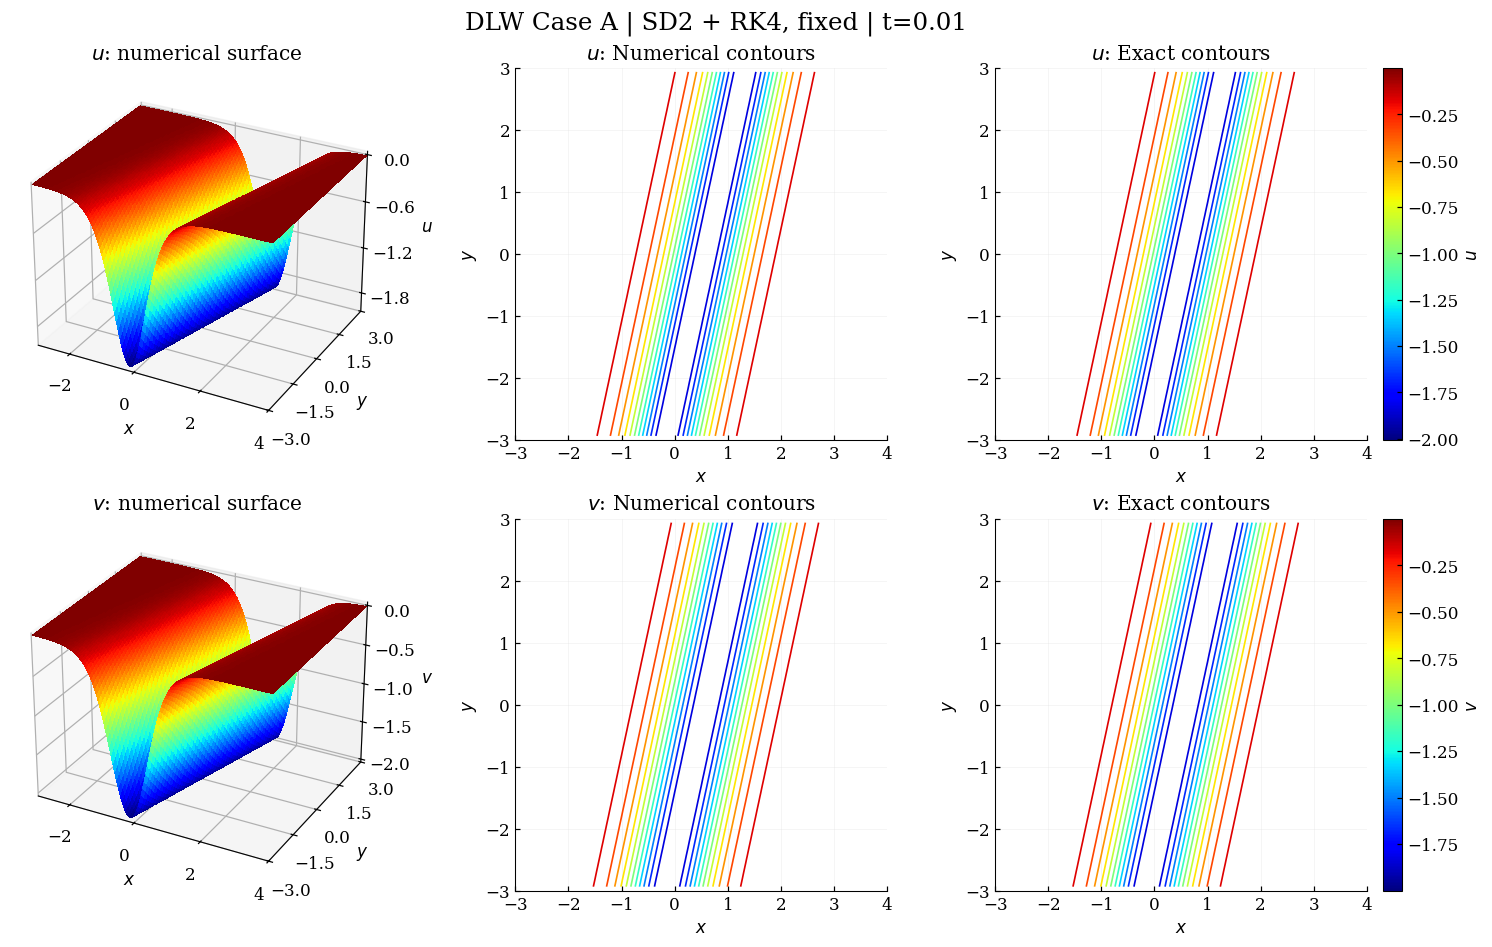

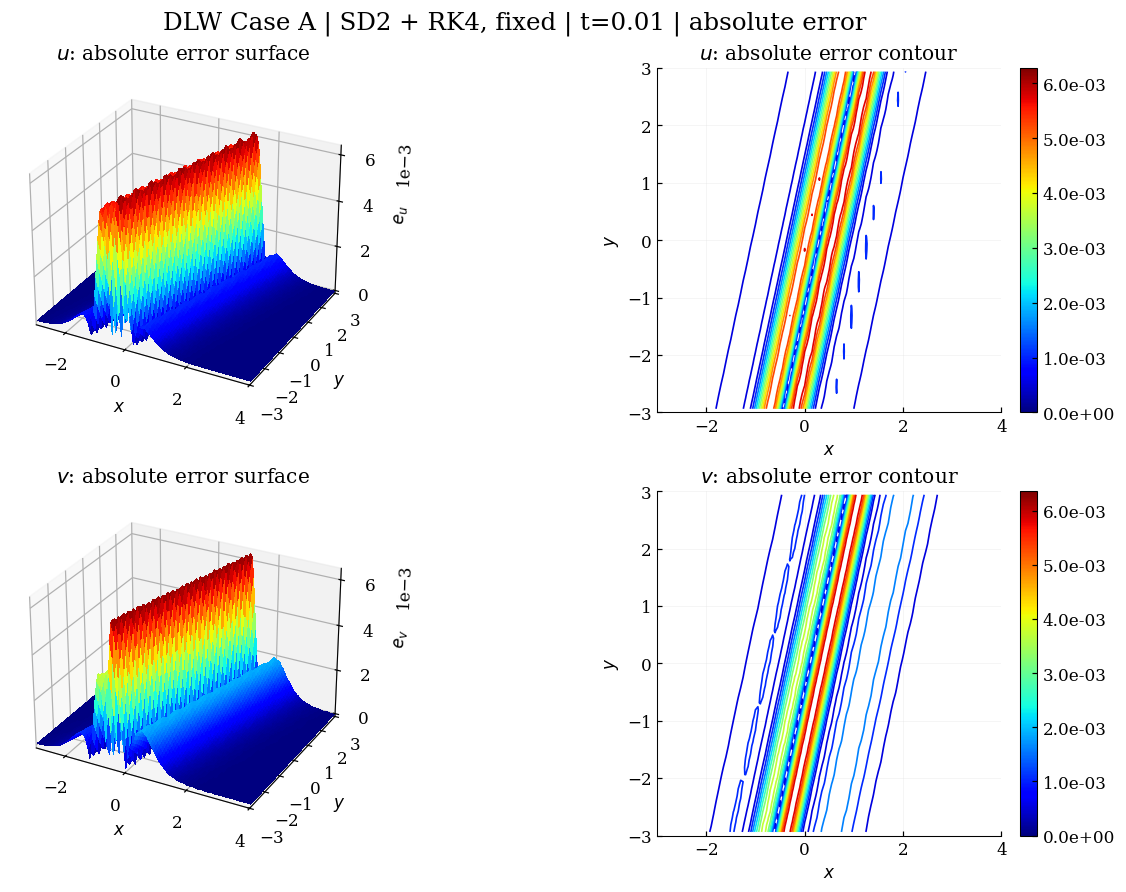

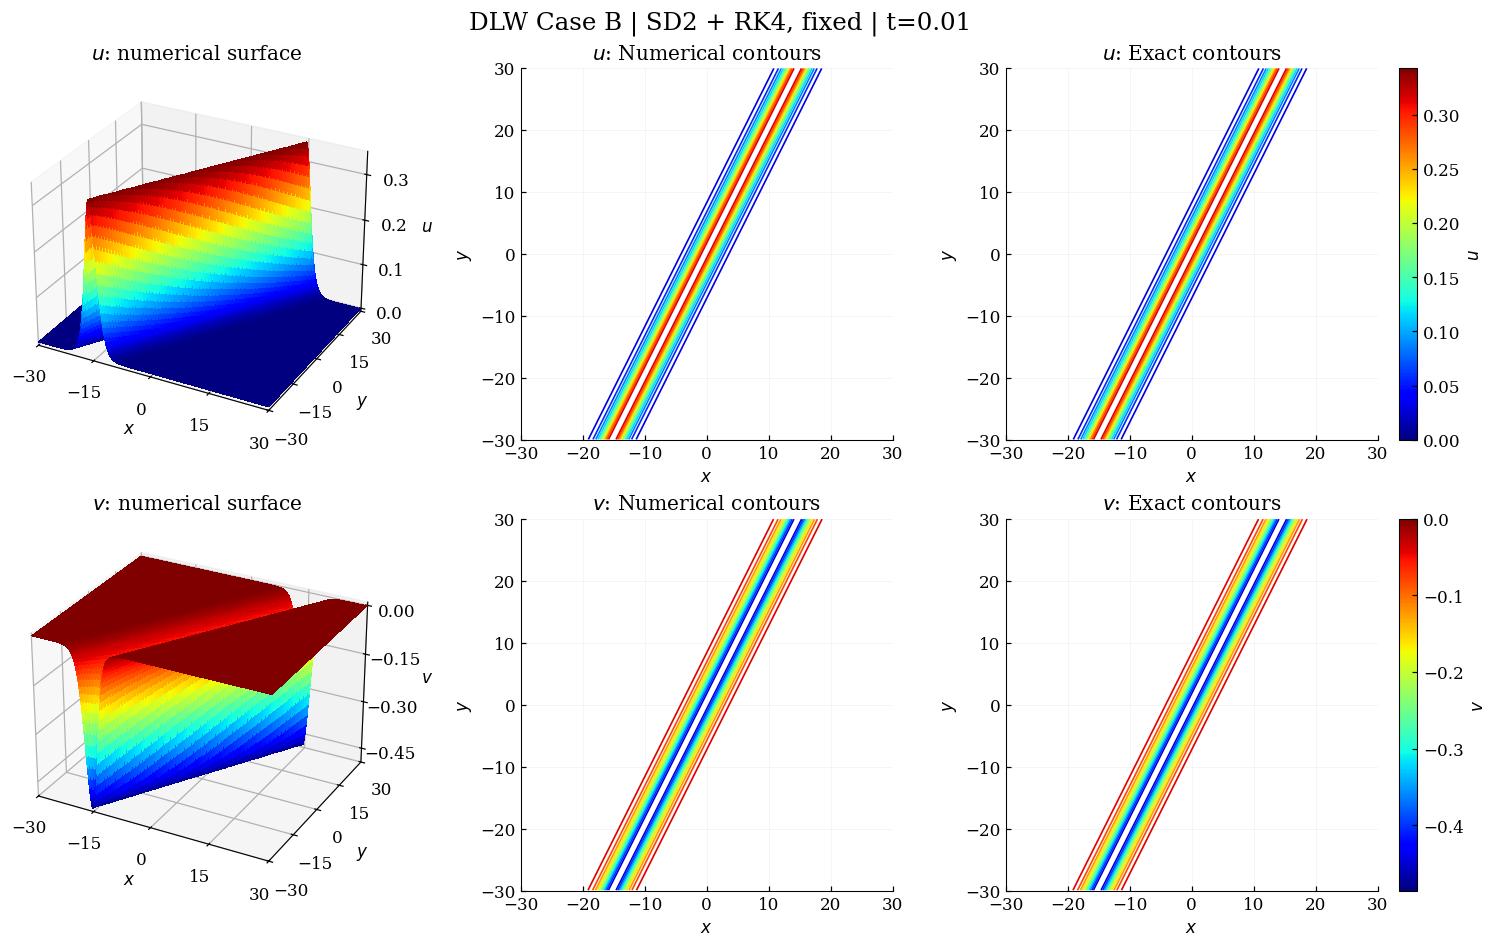

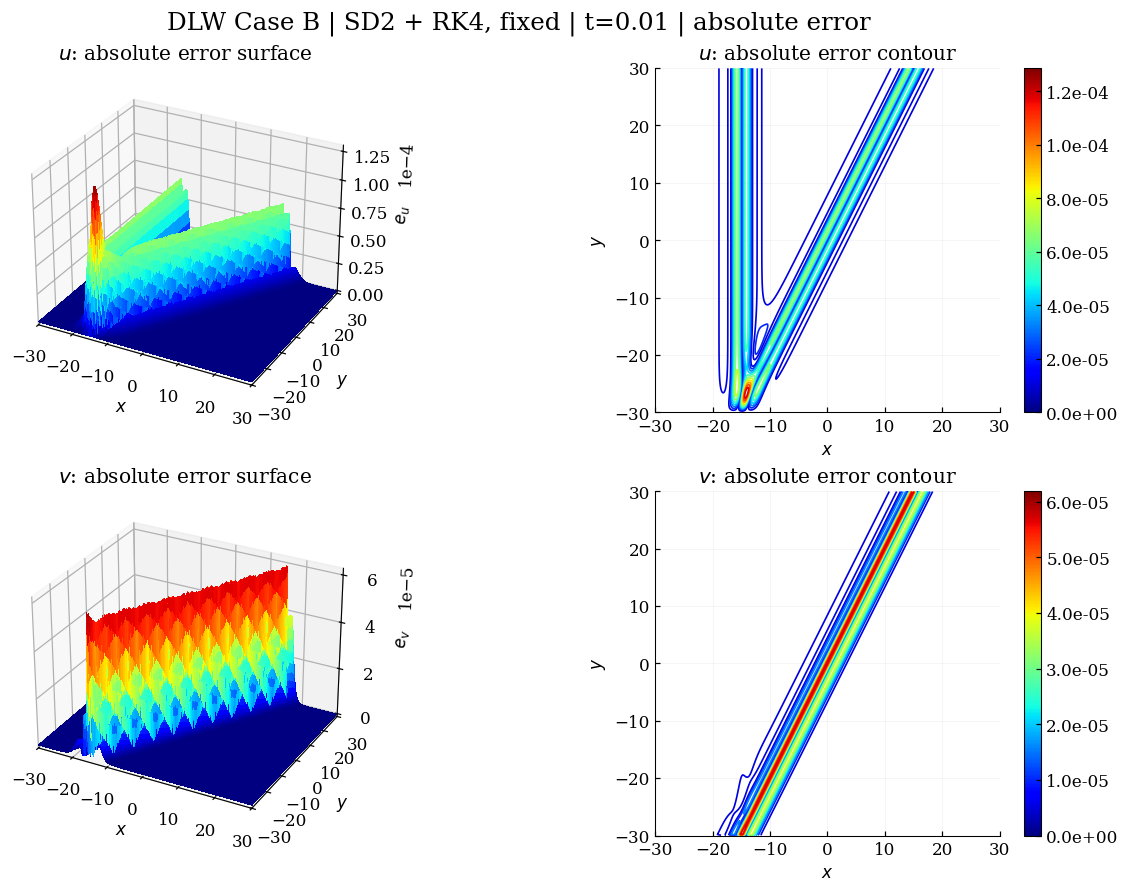

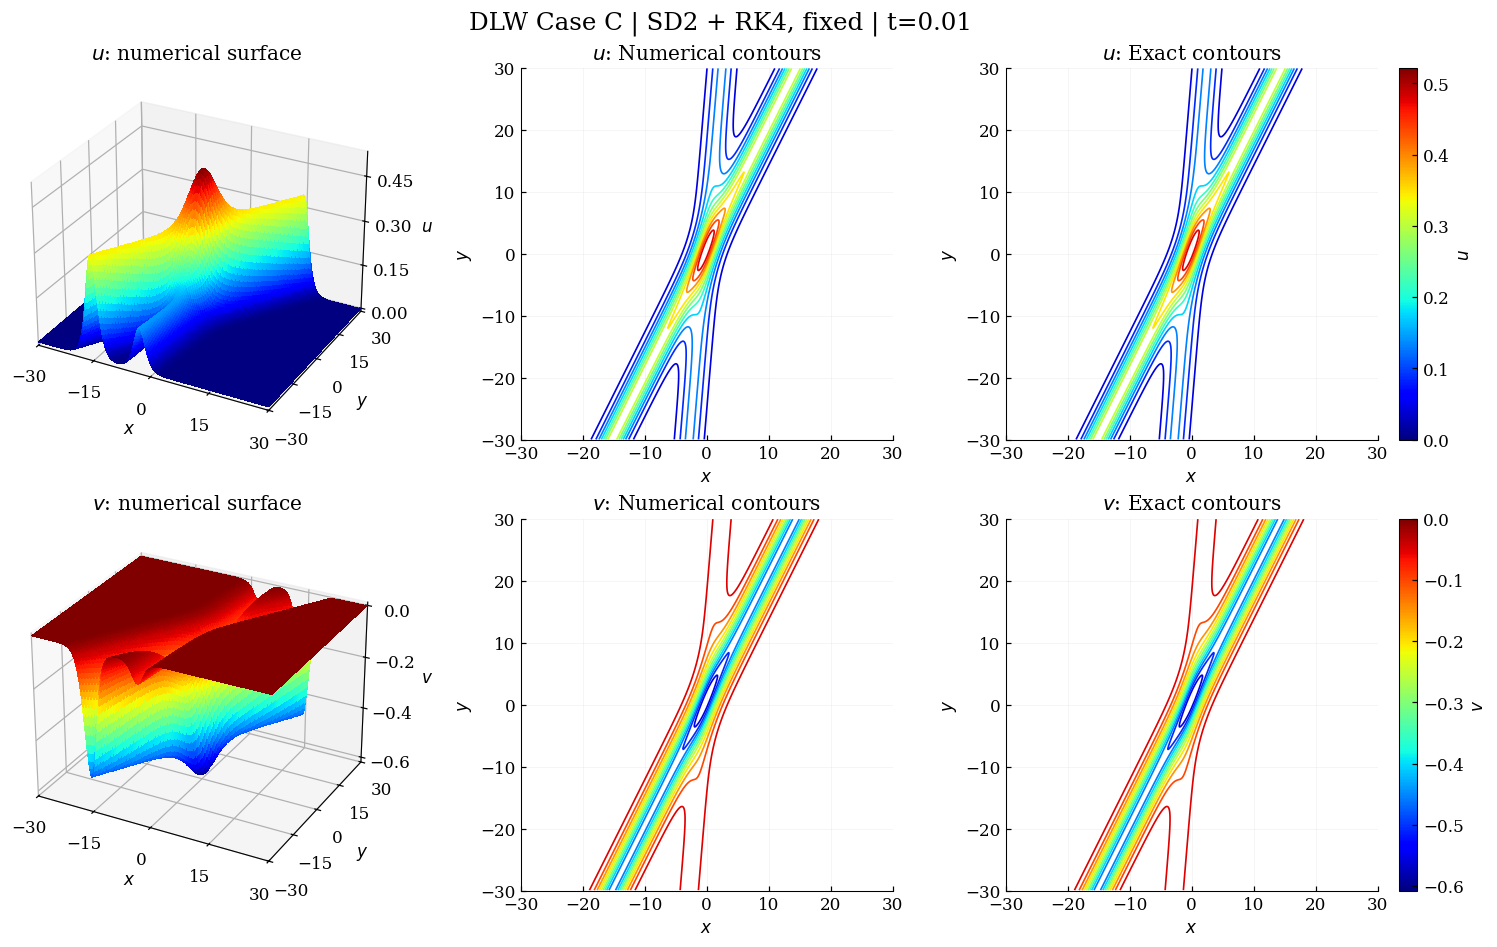

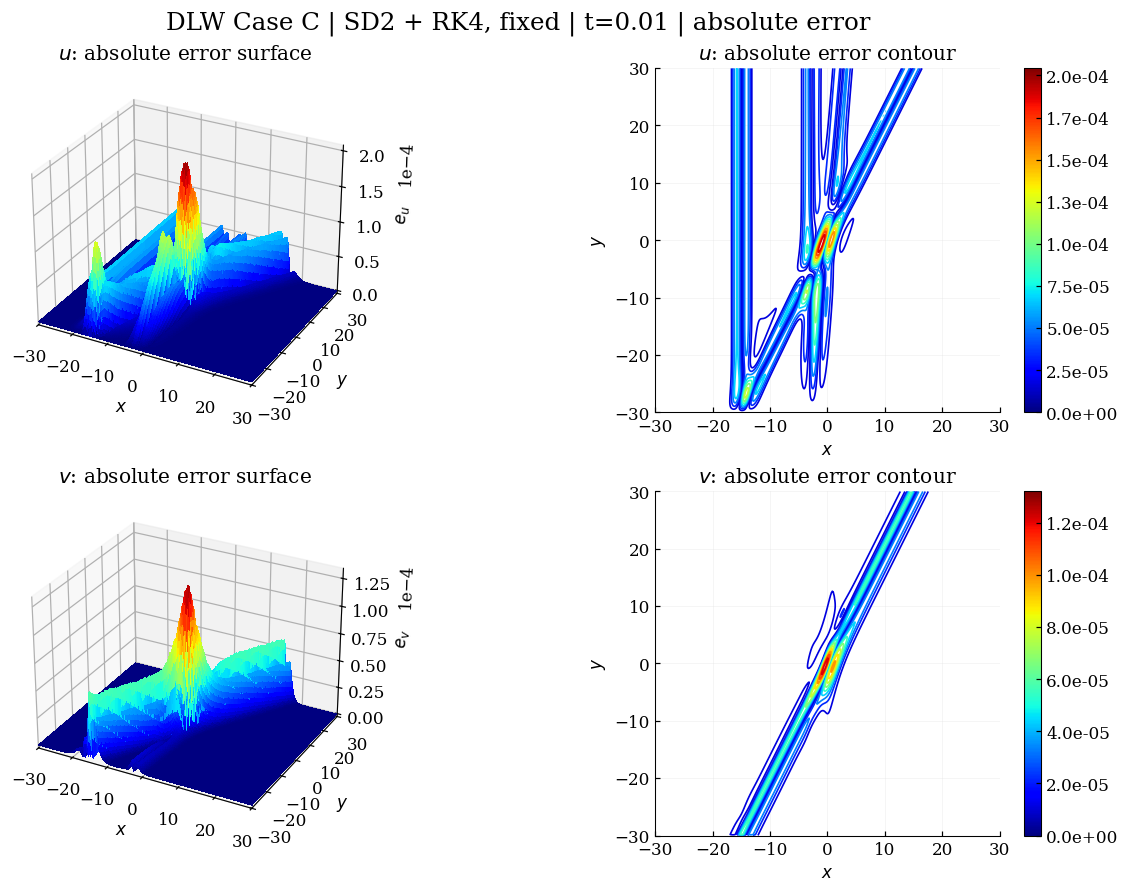

In [6]:
# 范围检查基于缓存建立时的计算参数，避免使用尚未重新计算的新参数。
saved_field_config = dict(field_signature[0])
for field_case in PLOT_CONFIG['cases']:
    record = dlw_field_cache[field_signature, field_case]
    drawing = dict(PLOT_CONFIG, **PLOT_CONFIG['windows'][field_case])
    checked_window(drawing['xlim'], (-saved_field_config['eval_half'], saved_field_config['eval_half']), f'{field_case}: xlim')
    checked_window(drawing['ylim'], (-saved_field_config['yhalf'], saved_field_config['yhalf']), f'{field_case}: ylim')
    draw_field_panels(record['x'], record['y'], record['fields'], record['exact'],
        f"DLW Case {field_case} | {record['model']} + {record['method']}, {record['mesh']} | t={record['reached']:g}",
        ('u', 'v'), drawing)